# Code-Capacity Damping Heat Map

This mirrors the random-error memory-coefficient heat-map notebook, but the disordered parameter now lives on message edges. The main sweep uses interval-sampled damping coefficients and scores logical success first, with exact recovery kept as a secondary diagnostic.


In [10]:
import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm


In [11]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "relay_bp").exists():
            return candidate
    raise FileNotFoundError("Could not locate the relay repo root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from relay_bp.analysis.code_capacity_common import default_export_code_paths

CODE_PATHS = {
    "hgp_625": Path(r"C:\Users\User\Documents\projects-git\giulio\hgp_code_625_25_6_peg.npz"),
    "hgp_225": Path(r"C:\Users\User\Documents\cluster_decoder\cluster_decoder\codes\hgp_code_225.npz"),
    "surface5": Path(r"C:\Users\User\Documents\Code from BPGD\surface5_HxHzLxLz.npz"),
    "surface13": Path(r"C:\Users\User\Documents\Code from BPGD\surface13_HxHzLxLz.npz"),
    "B1": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\B1_HxHzLxLz.npz"),
    "gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\gross_HxHzLxLz.npz"),
    "two_gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\two_gross_HxHzLxLz.npz"),
}

selected_code = "gross"  # change here
npz_path = CODE_PATHS[selected_code]

p_random_error = 0.06
prior_error_rate = p_random_error
max_iter = 40
alpha = 1.0

center_values = np.linspace(0.0, 1.00, 11)
width_values = np.linspace(0.00, 2.00, 11)
random_draws_per_point = 100
n_error_samples = 100
base_seed = 0

show_progress = True
show_inner_case_progress = False

sample_limit = None  # set to an integer for a quick smoke run

assert np.all((0.0 <= center_values) & (center_values <= 1.0)), "center_values must stay inside [0, 1]."
assert np.all(width_values >= 0.0), "All width values must be non-negative."
assert np.all(np.diff(center_values) >= 0), "center_values must be sorted."
assert np.all(np.diff(width_values) >= 0), "width_values must be sorted."
assert n_error_samples > 0, "n_error_samples must be positive."


In [12]:
import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "relay_bp").exists():
            return candidate
    raise FileNotFoundError("Could not locate the relay repo root from the current working directory.")


REPO_ROOT = globals().get("REPO_ROOT", find_repo_root(Path.cwd()))
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import relay_bp.analysis.code_capacity_common as code_capacity_common_module
import relay_bp.analysis.code_capacity_damping as code_capacity_damping_module

importlib.reload(code_capacity_common_module)
importlib.reload(code_capacity_damping_module)

from relay_bp.analysis.code_capacity_common import (
    default_export_code_paths,
    load_code_capacity_problem,
    sample_random_error_cases,
)
from relay_bp.analysis.code_capacity_damping import (
    evaluate_interval_heatmap,
    heatmap_rows,
)

CODE_PATHS = globals().get("CODE_PATHS", default_export_code_paths(REPO_ROOT))
selected_code = globals().get("selected_code", "gross")
npz_path = globals().get("npz_path", CODE_PATHS[selected_code])
p_random_error = float(globals().get("p_random_error", 0.06))
prior_error_rate = float(globals().get("prior_error_rate", p_random_error))
max_iter = int(globals().get("max_iter", 40))
alpha = float(globals().get("alpha", 1.0))
center_values = np.asarray(globals().get("center_values", np.linspace(0.50, 1.00, 11)), dtype=np.float64)
width_values = np.asarray(globals().get("width_values", np.linspace(0.00, 0.50, 11)), dtype=np.float64)
random_draws_per_point = int(globals().get("random_draws_per_point", 2))
n_error_samples = int(globals().get("n_error_samples", 300))
base_seed = int(globals().get("base_seed", 0))
show_progress = bool(globals().get("show_progress", False))
show_inner_case_progress = bool(globals().get("show_inner_case_progress", False))
sample_limit = globals().get("sample_limit", None)


def load_css_code(path: Path) -> dict[str, object]:
    problem = load_code_capacity_problem(path, default_prior_error_rate=prior_error_rate)
    return {
        "problem": problem,
        "hx": problem.hx,
        "hz": problem.hz,
        "lz": problem.lz,
        "metadata": problem.metadata,
        "error_priors": problem.error_priors,
    }


def sample_statistics(cases: list[dict[str, object]]) -> pd.DataFrame:
    error_weights = np.asarray([case["error_weight"] for case in cases], dtype=int)
    syndrome_weights = np.asarray([case["syndrome_weight"] for case in cases], dtype=int)
    return pd.DataFrame(
        [
            {
                "code": selected_code,
                "n_samples": int(len(cases)),
                "p_random_error": float(p_random_error),
                "mean_error_weight": float(error_weights.mean()) if len(error_weights) else np.nan,
                "mean_syndrome_weight": float(syndrome_weights.mean()) if len(syndrome_weights) else np.nan,
                "zero_error_rate": float((error_weights == 0).mean()) if len(error_weights) else np.nan,
                "zero_syndrome_rate": float((syndrome_weights == 0).mean()) if len(syndrome_weights) else np.nan,
                "max_error_weight": int(error_weights.max()) if len(error_weights) else -1,
                "max_syndrome_weight": int(syndrome_weights.max()) if len(syndrome_weights) else -1,
            }
        ]
    )


def sample_manifest(cases: list[dict[str, object]]) -> pd.DataFrame:
    rows = []
    for case in cases:
        rows.append(
            {
                "sample_idx": int(case["sample_idx"]),
                "error_weight": int(case["error_weight"]),
                "syndrome_weight": int(case["syndrome_weight"]),
                "error_support": np.flatnonzero(case["error"]).astype(int).tolist(),
            }
        )
    return pd.DataFrame(rows)


def evaluate_parameter_heatmaps(cases: list[dict[str, object]], check_matrix, lz_matrix) -> dict[str, object]:
    del check_matrix, lz_matrix
    return evaluate_interval_heatmap(
        problem=code_data["problem"],
        cases=cases,
        max_iter=max_iter,
        alpha=alpha,
        centers=center_values.tolist(),
        widths=width_values.tolist(),
        base_seed=base_seed,
        random_draws_per_point=random_draws_per_point,
        support_only=False,
        show_progress=show_progress,
        show_inner_case_progress=show_inner_case_progress,
    )


def grid_table(artifact: dict[str, object]) -> pd.DataFrame:
    return pd.DataFrame(heatmap_rows(artifact)).sort_values(
        ["logical_success_rate", "convergence_rate", "exact_recovery_rate", "mean_iterations"],
        ascending=[False, False, False, True],
    )


def best_points_table(artifact: dict[str, object], top_k: int = 8) -> pd.DataFrame:
    return grid_table(artifact).head(int(top_k)).reset_index(drop=True)


def plot_parameter_heatmaps(artifact: dict[str, object]):
    metrics = [
        ("logical_success_rate", "Logical success rate"),
        ("convergence_rate", "Convergence rate"),
        ("exact_recovery_rate", "Exact recovery rate"),
        ("mean_iterations", "Mean iterations"),
    ]
    centers = np.asarray(artifact["centers"], dtype=np.float64)
    widths = np.asarray(artifact["widths"], dtype=np.float64)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    for axis, (metric_key, title) in zip(axes.flat, metrics):
        image = axis.imshow(
            np.asarray(artifact[metric_key], dtype=np.float64),
            origin="lower",
            aspect="auto",
            extent=[float(centers.min()), float(centers.max()), float(widths.min()), float(widths.max())],
            cmap="viridis",
        )
        axis.set_title(title)
        axis.set_xlabel("interval center")
        axis.set_ylabel("interval width")
        fig.colorbar(image, ax=axis, shrink=0.85)
    fig.suptitle(f"{selected_code}: disordered damping heat maps", fontsize=14)
    return fig


code_data = load_css_code(npz_path)
hz_check_matrix = code_data["hz"]
lz_matrix = code_data["lz"]
random_error_cases = sample_random_error_cases(
    code_data["problem"],
    num_samples=n_error_samples,
    error_rate=p_random_error,
    base_seed=base_seed,
)
if sample_limit is not None:
    random_error_cases = random_error_cases[: int(sample_limit)]
sample_stats_df = sample_statistics(random_error_cases)
sample_manifest_df = sample_manifest(random_error_cases)


_smoke_problem = load_code_capacity_problem(CODE_PATHS["gross"])
_smoke_cases = sample_random_error_cases(_smoke_problem, num_samples=2, error_rate=0.03, base_seed=11)
_smoke_artifact = evaluate_interval_heatmap(
    problem=_smoke_problem,
    cases=_smoke_cases,
    max_iter=8,
    alpha=1.0,
    centers=[0.75],
    widths=[0.10],
    base_seed=5,
    random_draws_per_point=1,
    support_only=False,
)
assert _smoke_artifact["logical_success_rate"].shape == (1, 1)
assert int(_smoke_artifact["trial_count"][0, 0]) == len(_smoke_cases)


## Random Error Sample Summary


In [13]:
display(sample_stats_df)
display(sample_manifest_df.head(20))


,code,n_samples,p_random_error,mean_error_weight,mean_syndrome_weight,zero_error_rate,zero_syndrome_rate,max_error_weight,max_syndrome_weight
0,gross,100,0.06,8.55,18.81,0.0,0.0,16,32


,sample_idx,error_weight,syndrome_weight,error_support
0,0,11,21,"[2, 3, 11, 13, 20, 53, 59, 92, 108, 111, 113]"
1,1,5,11,"[9, 36, 61, 75, 93]"
2,2,13,19,"[7, 49, 64, 80, 84, 86, 89, 93, 97, 106, 117, ..."
3,3,5,13,"[20, 28, 74, 89, 104]"
4,4,2,6,"[51, 116]"
5,5,12,24,"[4, 7, 8, 29, 31, 48, 88, 111, 112, 129, 130, ..."
6,6,7,15,"[10, 12, 16, 46, 50, 83, 127]"
7,7,11,19,"[6, 23, 24, 32, 37, 52, 90, 96, 98, 114, 120]"
8,8,6,16,"[24, 39, 104, 124, 127, 136]"
9,9,8,18,"[8, 12, 58, 67, 69, 88, 102, 135]"


## Coefficient Heat Maps


heatmap grid: 100%|██████████| 121/121 [11:00<00:00,  5.46s/it, center=1.000, conv=0.971, logical=0.896, width=2.000]


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
0,0.2,1.4,0.0,0.9,0.9352,0.9642,0.8651,1.5232,10000
1,1.0,1.8,0.1,1.0,0.9292,0.9643,0.8828,1.5154,10000
2,0.2,1.0,0.0,0.7,0.9290,0.9577,0.8443,1.7983,10000
3,0.5,0.8,0.1,0.9,0.9246,0.9733,0.8473,1.1486,10000
4,1.0,1.4,0.3,1.0,0.9238,0.9692,0.8484,1.3117,10000
5,0.7,0.8,0.3,1.0,0.9237,0.9646,0.8654,1.4948,10000
6,0.8,2.0,0.0,1.0,0.9234,0.9720,0.8647,1.2152,10000
7,0.6,0.4,0.4,0.8,0.9208,0.9695,0.8608,1.2942,10000


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
79,0.2,1.4,0.0,0.9,0.9352,0.9642,0.8651,1.5232,10000
109,1.0,1.8,0.1,1.0,0.9292,0.9643,0.8828,1.5154,10000
57,0.2,1.0,0.0,0.7,0.9290,0.9577,0.8443,1.7983,10000
49,0.5,0.8,0.1,0.9,0.9246,0.9733,0.8473,1.1486,10000
87,1.0,1.4,0.3,1.0,0.9238,0.9692,0.8484,1.3117,10000
51,0.7,0.8,0.3,1.0,0.9237,0.9646,0.8654,1.4948,10000
118,0.8,2.0,0.0,1.0,0.9234,0.9720,0.8647,1.2152,10000
28,0.6,0.4,0.4,0.8,0.9208,0.9695,0.8608,1.2942,10000
97,0.9,1.6,0.1,1.0,0.9199,0.9608,0.8498,1.6474,10000
105,0.6,1.8,0.0,1.0,0.9195,0.9633,0.8393,1.5634,10000


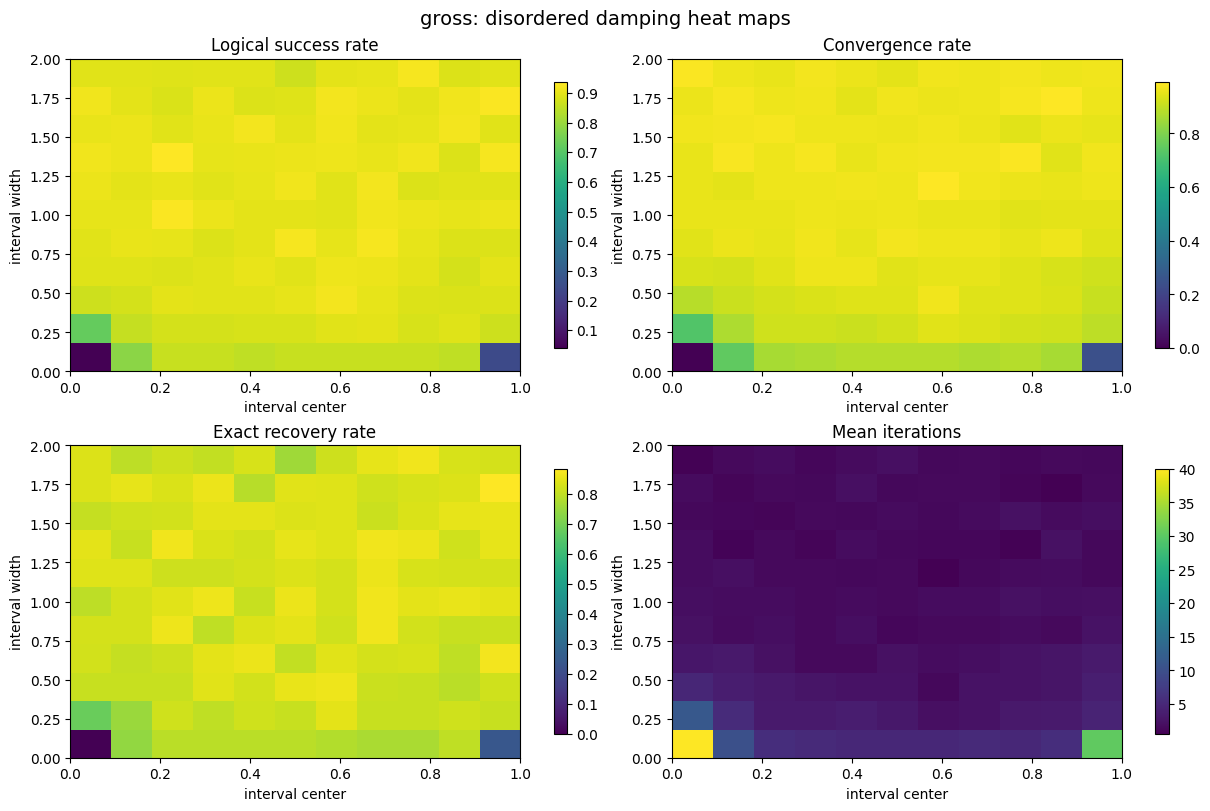

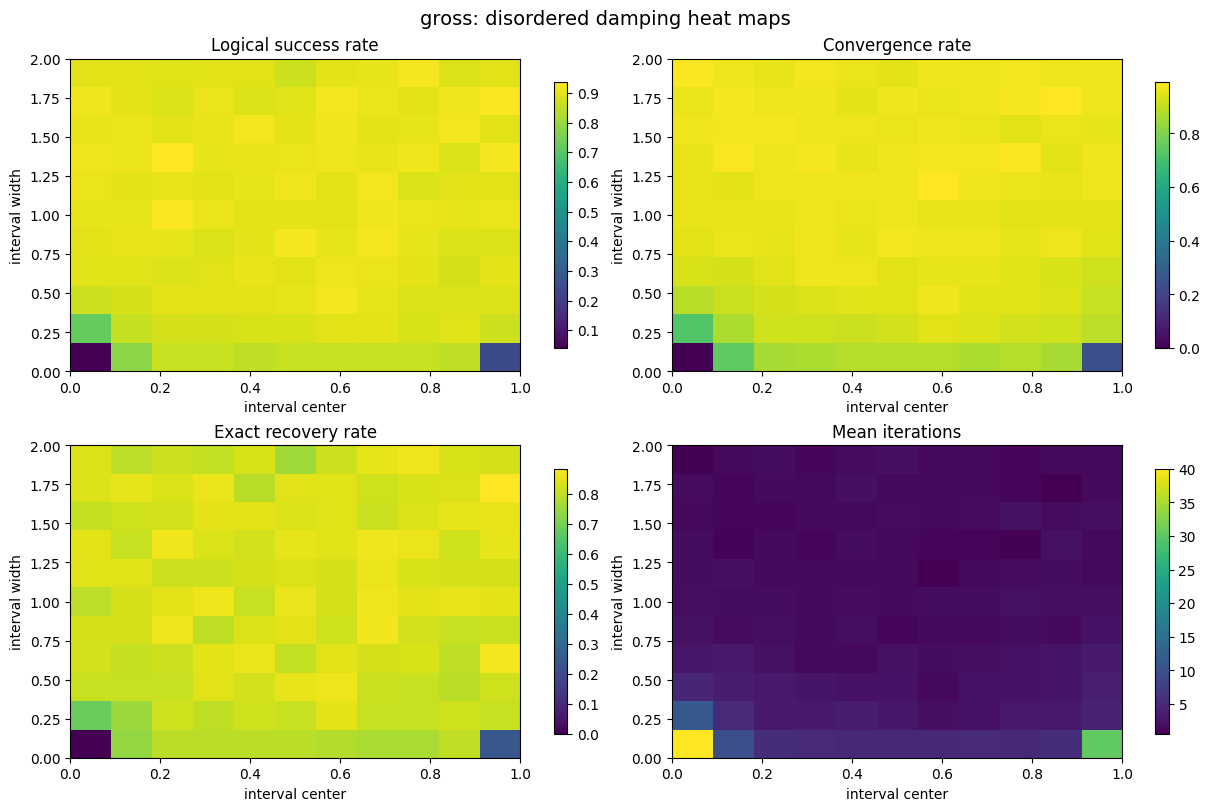

In [14]:
artifact = evaluate_parameter_heatmaps(random_error_cases, hz_check_matrix, lz_matrix)
heatmap_df = grid_table(artifact)
best_points_df = best_points_table(artifact)

display(best_points_df)
display(heatmap_df.head(16))
fig = plot_parameter_heatmaps(artifact)
fig


## Optional Extension

One useful follow-up, kept at the end so the main flow stays familiar: compare the best disordered interval against the scalar-damping slice at the same center. That separates "interval disorder helps" from "the best point just moved the average damping."


In [7]:
best_point = best_points_df.iloc[0]
scalar_artifact = evaluate_interval_heatmap(
    problem=code_data["problem"],
    cases=random_error_cases,
    max_iter=max_iter,
    alpha=alpha,
    centers=[float(best_point["center"])],
    widths=[0.0],
    base_seed=base_seed,
    random_draws_per_point=random_draws_per_point,
    support_only=False,
    show_progress=show_progress,
    show_inner_case_progress=show_inner_case_progress,
)
scalar_row = pd.DataFrame(heatmap_rows(scalar_artifact)).iloc[0]
comparison_df = pd.DataFrame(
    [
        {
            "setting": "best disordered interval",
            "center": float(best_point["center"]),
            "width": float(best_point["width"]),
            "logical_success_rate": float(best_point["logical_success_rate"]),
            "convergence_rate": float(best_point["convergence_rate"]),
            "exact_recovery_rate": float(best_point["exact_recovery_rate"]),
            "mean_iterations": float(best_point["mean_iterations"]),
        },
        {
            "setting": "same-center scalar damping",
            "center": float(scalar_row["center"]),
            "width": float(scalar_row["width"]),
            "logical_success_rate": float(scalar_row["logical_success_rate"]),
            "convergence_rate": float(scalar_row["convergence_rate"]),
            "exact_recovery_rate": float(scalar_row["exact_recovery_rate"]),
            "mean_iterations": float(scalar_row["mean_iterations"]),
        },
    ]
)
display(comparison_df)


heatmap grid: 100%|██████████| 1/1 [00:00<00:00,  2.63it/s, center=0.800, conv=0.870, logical=0.850, width=0.000]


,setting,center,width,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations
0,best disordered interval,0.8,0.6,0.875,0.898333,0.778333,7.178333
1,same-center scalar damping,0.8,0.0,0.850,0.870000,0.753333,8.043333


heatmap grid: 100%|██████████| 20/20 [16:45<00:00, 50.26s/it, center=0.800, conv=1.000, logical=0.997, width=1.000]


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
0,0.8,0.2,0.7,0.9,0.99986,0.99986,0.98492,0.03095,100000
1,0.8,0.6,0.5,1.0,0.99898,0.99997,0.98597,0.02644,100000
2,0.4,0.4,0.2,0.6,0.99898,0.99997,0.98497,0.02895,100000
3,0.4,0.6,0.1,0.7,0.99897,0.99997,0.98599,0.03162,100000
4,0.6,0.4,0.4,0.8,0.99897,0.99997,0.98297,0.02413,100000
5,0.6,0.2,0.5,0.7,0.99894,0.99994,0.98594,0.02492,100000
6,0.6,0.8,0.2,1.0,0.99893,0.99993,0.98394,0.02873,100000
7,0.4,0.2,0.3,0.5,0.99892,0.99987,0.98692,0.03135,100000


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
3,0.8,0.2,0.7,0.9,0.99986,0.99986,0.98492,0.03095,100000
11,0.8,0.6,0.5,1.0,0.99898,0.99997,0.98597,0.02644,100000
5,0.4,0.4,0.2,0.6,0.99898,0.99997,0.98497,0.02895,100000
9,0.4,0.6,0.1,0.7,0.99897,0.99997,0.98599,0.03162,100000
6,0.6,0.4,0.4,0.8,0.99897,0.99997,0.98297,0.02413,100000
2,0.6,0.2,0.5,0.7,0.99894,0.99994,0.98594,0.02492,100000
14,0.6,0.8,0.2,1.0,0.99893,0.99993,0.98394,0.02873,100000
1,0.4,0.2,0.3,0.5,0.99892,0.99987,0.98692,0.03135,100000
4,0.2,0.4,0.0,0.4,0.99883,0.99981,0.98285,0.07165,100000
8,0.2,0.6,0.0,0.5,0.99848,0.99948,0.97948,0.07265,100000


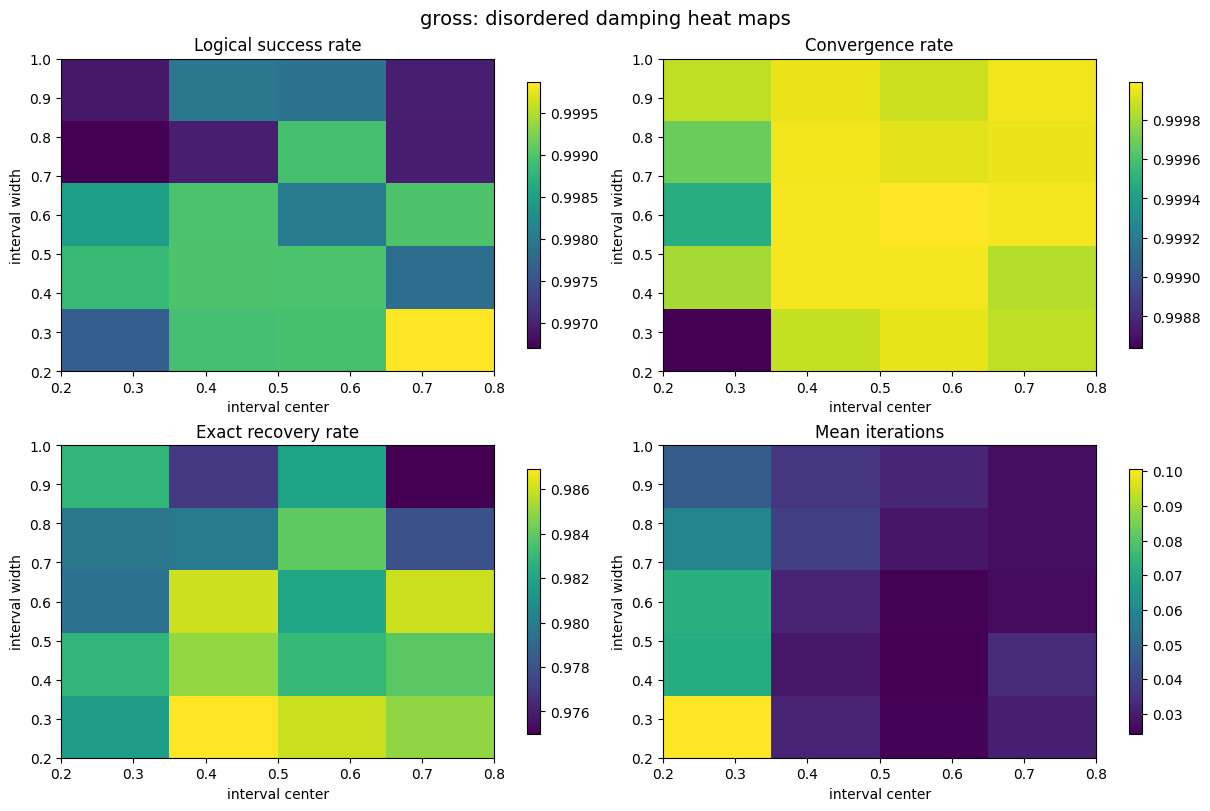

In [ ]:
p_random_error = 0.03
prior_error_rate = p_random_error
max_iter = 40
alpha = 1.0

center_values = np.linspace(0.2, 0.8, 4)
width_values = np.linspace(0.2, 1.00, 5)
random_draws_per_point = 100
n_error_samples = 1000
base_seed = 0


random_error_cases = sample_random_error_cases(
    code_data["problem"],
    num_samples=n_error_samples,
    error_rate=p_random_error,
    base_seed=base_seed,
)


show_progress = True
show_inner_case_progress = False

sample_limit = None  # set to an integer for a quick smoke run

assert np.all((0.0 <= center_values) & (center_values <= 1.0)), "center_values must stay inside [0, 1]."
assert np.all(width_values >= 0.0), "All width values must be non-negative."
assert np.all(np.diff(center_values) >= 0), "center_values must be sorted."
assert np.all(np.diff(width_values) >= 0), "width_values must be sorted."
assert n_error_samples > 0, "n_error_samples must be positive."


artifact = evaluate_parameter_heatmaps(random_error_cases, hz_check_matrix, lz_matrix)
heatmap_df = grid_table(artifact)
best_points_df = best_points_table(artifact)

display(best_points_df)
display(heatmap_df.head(16))
fig = plot_parameter_heatmaps(artifact)

heatmap grid: 100%|██████████| 2/2 [15:57<00:00, 478.78s/it, center=0.800, conv=1.000, logical=0.999, width=0.600]


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
0,0.8,0.2,0.7,0.9,0.999989,0.999989,0.985989,0.003030,1000000
1,0.8,0.6,0.5,1.0,0.998993,0.999993,0.985993,0.002877,1000000


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
0,0.8,0.2,0.7,0.9,0.999989,0.999989,0.985989,0.003030,1000000
1,0.8,0.6,0.5,1.0,0.998993,0.999993,0.985993,0.002877,1000000


C:\Users\User\AppData\Local\Temp\ipykernel_18968\4098299004.py:140: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  image = axis.imshow(


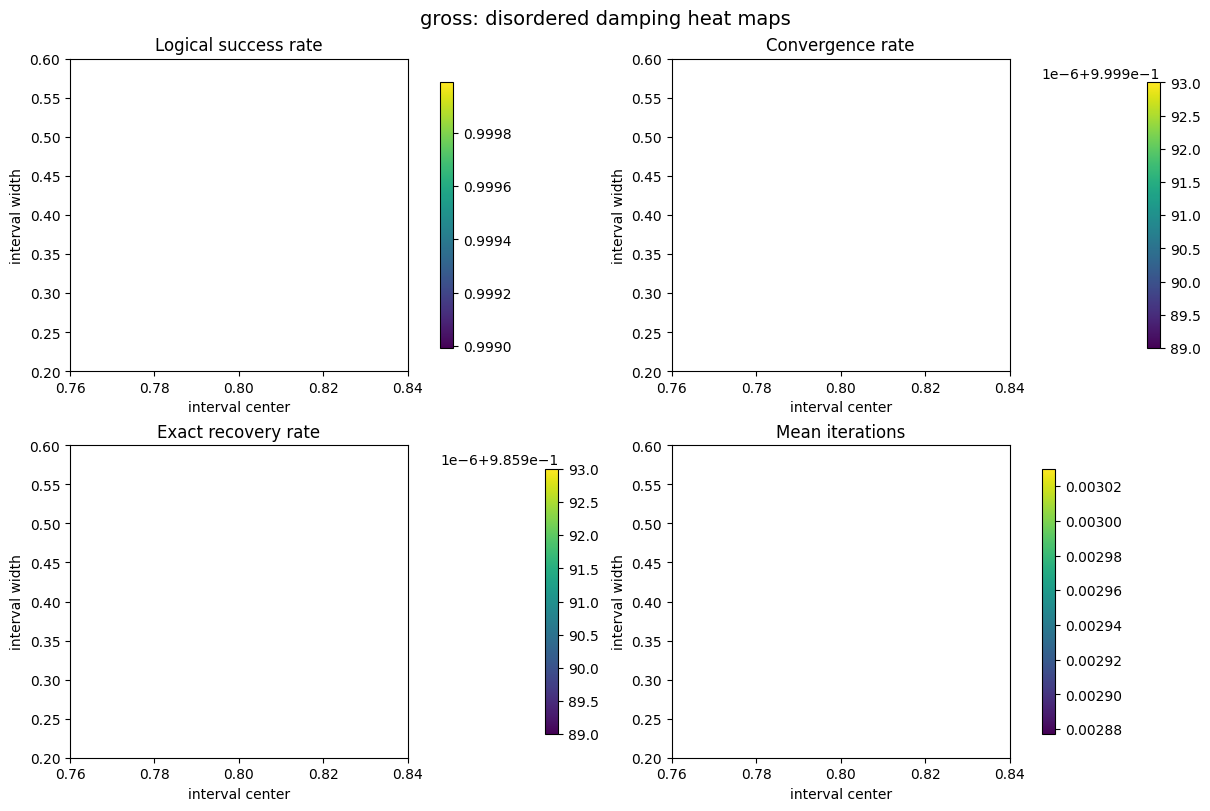

In [9]:
p_random_error = 0.03
prior_error_rate = p_random_error
max_iter = 40
alpha = 1.0

center_values = np.linspace(0.8, 0.8, 1)
width_values = np.linspace(0.2, 0.6, 2)
random_draws_per_point = 1000
n_error_samples = 1000
base_seed = 0


random_error_cases = sample_random_error_cases(
    code_data["problem"],
    num_samples=n_error_samples,
    error_rate=p_random_error,
    base_seed=base_seed,
)


show_progress = True
show_inner_case_progress = False

sample_limit = None  # set to an integer for a quick smoke run

assert np.all((0.0 <= center_values) & (center_values <= 1.0)), "center_values must stay inside [0, 1]."
assert np.all(width_values >= 0.0), "All width values must be non-negative."
assert np.all(np.diff(center_values) >= 0), "center_values must be sorted."
assert np.all(np.diff(width_values) >= 0), "width_values must be sorted."
assert n_error_samples > 0, "n_error_samples must be positive."


artifact = evaluate_parameter_heatmaps(random_error_cases, hz_check_matrix, lz_matrix)
heatmap_df = grid_table(artifact)
best_points_df = best_points_table(artifact)

display(best_points_df)
display(heatmap_df.head(16))
fig = plot_parameter_heatmaps(artifact)